In [1]:
#!!!!注意，請先執行這個區塊，依網頁指示通過授權後載入 Google 雲端硬碟, 再執行底下的程式
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# LSTM分類IMDB

#### 載入套件

In [2]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SpatialDropout1D
from tensorflow.keras.layers import LSTM # new!
from tensorflow.keras.callbacks import ModelCheckpoint
import os
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
%matplotlib inline

#### LSTM 分類模型的超參數

In [3]:
# 輸出目錄名稱：
output_dir = '/content/drive/MyDrive/_教材/人工智慧/自然語言程式/IMDB詞性分析範例/model_output/LSTM' #註：請記得依你存放的位置彈性修改路徑

# 訓練
epochs = 4
batch_size = 128

# 詞向量空間
n_dim = 64
n_unique_words = 10000
max_review_length = 100
pad_type = trunc_type = 'pre'
drop_embed = 0.2

# LSTM 層架構
n_lstm = 256
drop_lstm = 0.2

# 密集層架構:
# n_dense = 256
# dropout = 0.2

#### 載入資料集

In [4]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=n_unique_words)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### 預處理

In [5]:
x_train = pad_sequences(x_train, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)
x_test = pad_sequences(x_test, maxlen=max_review_length, padding=pad_type, truncating=trunc_type, value=0)

#### LSTM 分類模型架構

In [6]:
model = Sequential()
model.add(Embedding(n_unique_words, n_dim, input_length=max_review_length))
model.add(SpatialDropout1D(drop_embed))
model.add(LSTM(n_lstm, dropout=drop_lstm))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### 編譯模型

In [8]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
modelcheckpoint = ModelCheckpoint(filepath=output_dir+"/weights.{epoch:02d}.keras")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

#### 訓練模型

In [10]:
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test), callbacks=[modelcheckpoint])

Epoch 1/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.6551 - loss: 0.6018 - val_accuracy: 0.8301 - val_loss: 0.3916
Epoch 2/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.8742 - loss: 0.3084 - val_accuracy: 0.8210 - val_loss: 0.4642
Epoch 3/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9032 - loss: 0.2441 - val_accuracy: 0.8436 - val_loss: 0.3723
Epoch 4/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9232 - loss: 0.2047 - val_accuracy: 0.8437 - val_loss: 0.3869


#### 評估結果

In [11]:
#視以上執行結果指定較佳的權重
model.load_weights(output_dir+"/weights.03.keras")

In [12]:
y_hat = model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


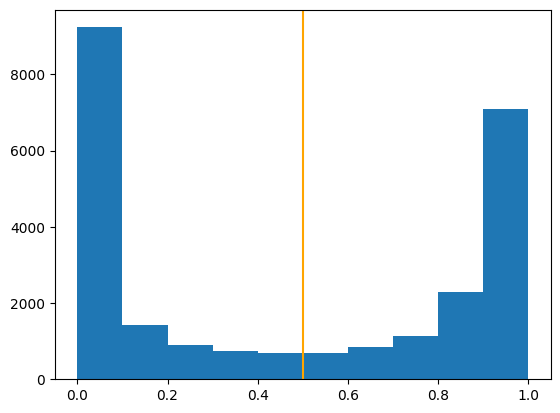

In [13]:
plt.hist(y_hat)
_ = plt.axvline(x=0.5, color='orange')

In [ ]:
"{:0.2f}".format(roc_auc_score(y_test, y_hat)*100.0)

'92.61'